# Keyframe Extraction

Select representative frames from raw video before running structure-from-motion. This notebook compares two strategies — fixed-rate (FPS) and optical-flow-driven — and shows how the choice affects spatial coverage of the resulting point cloud.

**Prerequisites:** a video file at `VIDEO_PATH` below; no GPU required for frame scoring.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

from collab_splats.utils.frame_sampling import (
    extract_video_frames,
    get_video_info,
    load_frame_scores,
    load_video_frames,
    sample_frames_fps,
    sample_frames_optical_flow,
    save_frame_scores,
    score_all_frames,
    plot_frame_grid,
    plot_selection,
    plot_frame_scores,
    plot_disparity_sensitivity,
)
from collab_splats.utils.paths import get_cache_dir

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
VIDEO_PATH   = "/workspace/fieldwork-data/birds/2024-02-06/SplatsSD/C0043.MP4"
DATASET      = "birds_c0043"

CACHE_DIR    = get_cache_dir(DATASET)
IMAGES       = CACHE_DIR / "images"
FRAME_SCORES = CACHE_DIR / "frame_scores.json"

## §0 — Why Frame Selection Matters

COLMAP (the structure-from-motion tool underlying most 3D reconstruction pipelines) builds a point cloud by finding matching features across frames. **The frames you give it determine the shape, density, and coverage of the result.**

Two failure modes:
- **Over-sampling slow regions:** A slow camera pan generates dozens of nearly identical frames. COLMAP spends budget on redundant matches; the resulting point cloud is dense in that region and sparse elsewhere.
- **Under-sampling fast transitions:** If the camera moves quickly through a room and you sample at fixed rate, interesting transitions may get fewer frames than a stationary shot.

**Even (FPS) sampling** extracts frames at a fixed temporal rate — uniform in time but biased toward regions filmed slowly.

**Optical flow (OF) sampling** extracts frames only when the scene content changes significantly — uniform in content, regardless of filming speed.

## §1 — Load Video

Set paths, create cache directories, and inspect video metadata. All subsequent cells read from `VIDEO_PATH` and write outputs under `CACHE_DIR`.

In [ ]:
# Ensure cache dirs exist
CACHE_DIR.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)

# Load video metadata
info = get_video_info(VIDEO_PATH)
print(f"Cache: {CACHE_DIR.resolve()}")
print(f"Frames: {info['total_frames']}  FPS: {info['fps']:.1f}  Duration: {info['duration_s']:.1f}s")

Preview one frame per second to get a sense of scene content and camera motion before selecting keyframes.

In [ ]:
# Preview: 1 frame per second to survey scene content
preview_frames, _ = sample_frames_fps(VIDEO_PATH, fps=1.0, max_frames=12)
plot_frame_grid(preview_frames, title="Video preview (1 fps)")

## §2 — Even Sampling (FPS)

Extract frames at a fixed temporal rate. The result is uniformly spaced in time but biased toward regions filmed slowly — slow pans generate many redundant frames while fast transitions get few.

In [ ]:
TARGET_FPS = 2.0  # adjust to taste
fps_frames, fps_indices = sample_frames_fps(VIDEO_PATH, fps=TARGET_FPS)

print(f"FPS sampling selected {len(fps_frames)} frames")
plot_selection(info['total_frames'], fps_indices=fps_indices)

The timeline above shows *when* frames were selected. The grid below shows *what* those frames look like — useful for spotting redundant or blurry picks.

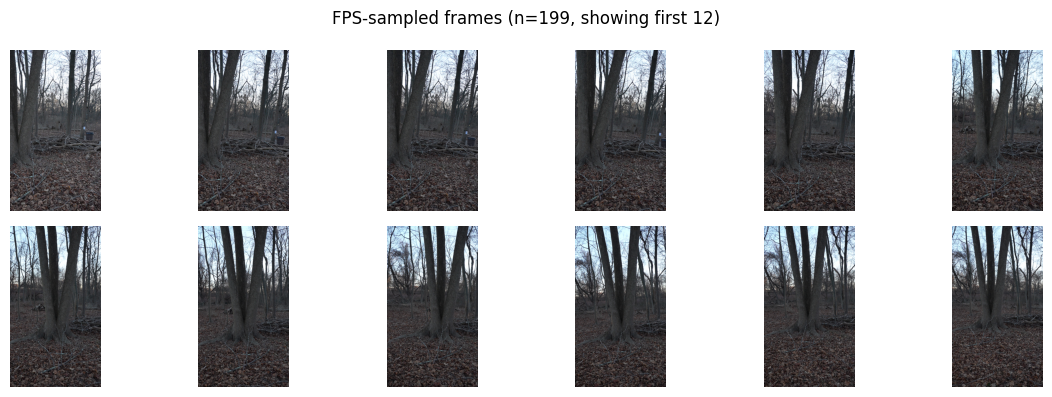

In [7]:
plot_frame_grid(fps_frames[:12], title=f"FPS-sampled frames (n={len(fps_frames)}, showing first 12)")

## §3 — Optical Flow Score Timeseries

Score every frame using optical flow before selecting keyframes. `score_all_frames` runs at `stride=5` by default — it scores every 5th frame for ~5× speedup with negligible quality loss on typical video. Three signals drive selection:
- **Disparity:** mean pixel displacement of tracked feature points — how much the camera moved
- **Rotation:** estimated camera rotation between frames
- **Histogram similarity:** how similar the current frame looks to the last accepted keyframe

Spikes indicate camera motion or scene change; flat regions indicate redundant frames.

In [ ]:
if FRAME_SCORES.exists():
    frame_scores = load_frame_scores(FRAME_SCORES)
    print(f"Loaded frame scores from cache ({len(frame_scores)} frames)")
else:
    frame_scores = score_all_frames(VIDEO_PATH)
    save_frame_scores(frame_scores, FRAME_SCORES)
    print(f"Scored frames → saved to {FRAME_SCORES}")

# Plot the three scoring signals over the video timeline
plot_frame_scores(frame_scores)

## §4 — Optical Flow Selection

Apply the selection threshold (`score ≥ 0.5`) to the scored frames to pick keyframes. Any frames not already cached in `IMAGES/` are extracted and saved as `frame_{idx:06d}.jpg`, preserving the original video frame index.

In [ ]:
# Derive selected indices from pre-scored frames
of_indices = [d["frame_idx"] for d in frame_scores if d["selected"]]

# Extract any OF frames not yet cached as frame_{idx:06d}.jpg
missing = [i for i in of_indices if not (IMAGES / f"frame_{i:06d}.jpg").exists()]
if missing:
    extract_video_frames(VIDEO_PATH, missing, IMAGES)
    print(f"Extracted {len(missing)} OF frames → {IMAGES}")

# Load OF frames by index from video (applies rotation automatically)
of_frames = load_video_frames(VIDEO_PATH, of_indices)
print(f"OF selection: {len(of_frames)} frames")

plot_selection(info['total_frames'], of_indices=of_indices)

Extract the selected keyframes from the video and write them to `IMAGES/`. Files are named `frame_{idx:06d}.jpg` where `idx` is the original video frame index — the same convention used by `extract_video_frames`. This step is skipped for any frames already cached.

In [ ]:
if not any(IMAGES.glob("*.jpg")):
    # Extract FPS-selected keyframes; swap fps_indices → of_indices to use OF selection for COLMAP
    # Files named frame_{idx:06d}.jpg, preserving original video frame index
    extract_video_frames(VIDEO_PATH, fps_indices, IMAGES)
    print(f"Extracted {len(list(IMAGES.glob('*.jpg')))} frames to {IMAGES}")
else:
    print(f"Using {len(list(IMAGES.glob('*.jpg')))} cached frames from {IMAGES}")

Grid view of the optical-flow-selected frames. Compare with the FPS grid above — OF tends to capture more visually distinct moments.

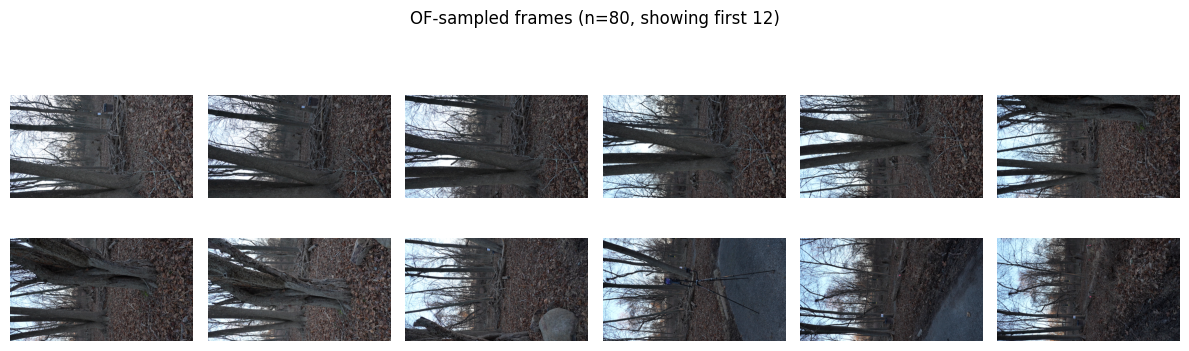

In [11]:
plot_frame_grid(of_frames[:12], title=f"OF-sampled frames (n={len(of_frames)}, showing first 12)")

## §5 — Side-by-Side Comparison

Overlay FPS and OF selections on the same timeline. FPS distributes uniformly in time; OF distributes uniformly in content — the difference is most visible where camera speed varies.

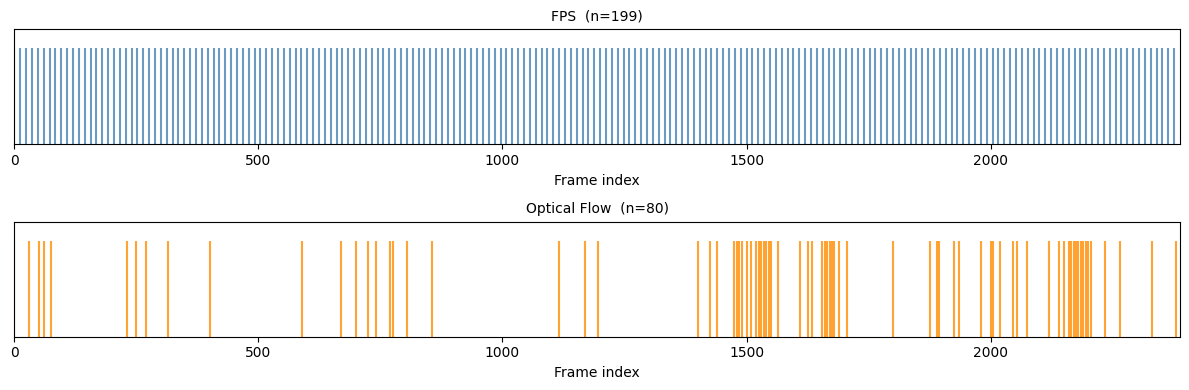

In [12]:
# Overlay FPS and OF selections on the same timeline
plot_selection(info['total_frames'], fps_indices=fps_indices, of_indices=of_indices)

## §6 — Parameter Sensitivity

`min_disparity` controls how much the camera must move before a new frame is accepted. Higher values yield fewer, more distinct frames; lower values give denser coverage at the cost of more redundancy.

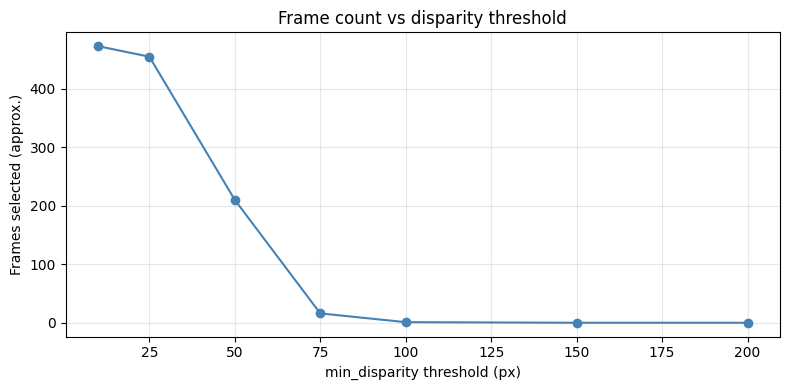

In [13]:
disparity_values = [10.0, 25.0, 50.0, 75.0, 100.0, 150.0, 200.0]
plot_disparity_sensitivity(frame_scores, disparity_values)

## §7 — When to Use Each Method

| Scenario | Recommended | Reason |
|----------|-------------|--------|
| Slow camera pans | Optical flow | Avoids oversampling near-identical frames |
| Handheld walk-through | Either | FPS is simpler; OF is marginally better |
| Fast action / drone | FPS | OF may miss fast transients between keyframes |
| Limited frame budget | Optical flow | Better spatial scene coverage per frame |

**Default in `SplatterConfig`:** `frame_selection="fps"`. Switch to `"optical_flow"` for indoor walk-throughs or any scene with significant speed variation.